# Exporting Land Cover summary statistics <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with the `DEA Sandbox` environment
* **Products used:** 
[ga_ls_landcover_class_cyear_3](https://explorer.dea.ga.gov.au/products/ga_ls_landcover_class_cyear_3)

## Background 
Land cover is the physical surface of the Earth, including trees, shrubs, grasses, soils, exposed rocks, water bodies, plantations, crops and built structures.

Digital Earth Australia Land Cover (DEA Land Cover) is a continental dataset that maps annual land cover classifications for Australia from 1988 to the present. 
Detailed information about DEA Land Cover can be found in the [DEA Land Cover notebook](../DEA_products/DEA_Land_Cover.ipynb) and on the [DEA Land Cover product details](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat) page.

Outputting land cover data summary statistics can be useful for further analysis, for example by combining the data with other data streams, such as census data from the Australian Bureau of Statistics. In this notebook we will export a **time series of summary land cover data** in tabular format for a region of interest (e.g. `outputname.csv`).

## Description 

This notebook demonstrates how to export [Land Cover](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat) time series of land cover data from the [Open Data Cube](https://www.opendatacube.org/) (ODC) for facilitating quantitative analyses. 

The worked example takes users through the code required to do the following: 

1. Select an area and time range of interest and load the Land Cover data from the Open Data Cube.
2. Further refine the area of interest using a polygon vector file
3. Select the DEA Land Cover classification level (refer to [Land Cover Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat/?tab=description) for class details) and the classes of interest for analysis
4. For each year, extract the number of pixels of each class of interest, together with the extent of those classes in squared metres, squared kilometres and hectares
5. Export the data as a `CSV` file for further analyses
6. Examples of data visualisation

This notebook requires a basic understanding of the DEA Land Cover data set. 
If you are new to DEA Land Cover, it is recommended you first look at the following notebooks: 

- [DEA_Land_Cover](../DEA_products/DEA_Land_Cover.ipynb)
- [Land_cover_pixel_drill](../How_to_guides/Land_cover_pixel_drill.ipynb)

***

## Getting started

To run this analysis, run all the cells in the notebook starting with the 'Load packages' and 'connect to the datacube' cells. Then, define custom functions that will be used later in the notebook.

### Load packages
Load key Python packages and supporting functions for the analysis.

In [1]:
%matplotlib inline
import sys
import os

import datacube
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import odc.geo.xr
from odc.geo.geom import Geometry

sys.path.insert(1, os.path.abspath("../Tools"))
from dea_tools.landcover import get_label, plot_land_cover, get_colour_scheme

### Connect to the datacube
Connect to the datacube so we can access DEA data. 

In [2]:
dc = datacube.Datacube(app="Land_cover_extract_data")

## Analysis Parameters


* `polygon_path` : A path to a vector file (ESRI Shapefile or GeoJSON), this will define the analysis extent.
* `ROI_id` : A name to give the region, we use this for naming the output data
* `lc_level` : Indicate which level of land cover measurement you want (either "level3" or "level4"). See further explanation below.
* `resolution` : The spatial resolution of the loaded satellite data e.g. for Landsat, this is `(-30, 30)`
* `time_range`: The date range to analyse (e.g. `('2000', '2023')`).
* `classes_list`: either 'all' or a list of class integers to extract. See further explanation below.

> Note: the polygon must be either be in EPSG:3577 (Albers equal area), or you must convert the xarray object to EPSG:3577 after loading, otherwise area statistics will be incorrect.

DEA Land Cover consists of two datasets: the base (Level 3) classification, and the final (Level 4) classification which combines the base classes with their associated descriptors. We will select the dataset we want to use, and the specific classes we want to include in the output table. For this exercise, we will focus on Natural Terrestrial Vegetation (NTV), Artificial Surface (AS), and Natural Bare Surface (NS).

To select the classes values corresponding to the land cover type of interest, please refer to the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat/?tab=description#technical-information).

Alternatively, to extract pixel counts for every class present in the ROI, you can input `all` to the variable `classes_list`, which was defined in the custom function in the previous cell.

In [3]:
# path to polygon file which is our region of study
polygon_path = (
    "../Supplementary_data/Land_cover_extract_data/Quinns_Rocks.gpkg")
ROI_id = "QuinnsRocks_WA"
time_range = ("2000", "2023")
resolution = 30
lc_level = "level3"

# looking at the DEA Knowledge Hub, we identified that level3 NTV is value 112, AS is 215, NS is 216. 
classes_list = [112, 215, 216]


### Define custom function

The following function will count how many pixels are within a region of interest (ROI) for each of the selected Land Cover classes. 

The pixel counts are then used to calculate the area covered by each class in squared metres, squared kilometres, and hectares.

In [4]:
def extract_data_from_roi(lc_ds, ROI_name, lc_level, classes_list='all'):
    '''
    This function counts the pixels for each Land Cover class within the defined area (ROI), for every year,
    and convert them into squared metres, squared kilometres and hectares.
    
    Parameters
    -------------------------
    lc_ds : xarray.DataArray
        A data cube containing the DEA Land Cover.
    ROI_name : string
        an ID for the area of interest
    lc_level : string
        the land cover level. Either 'level3', 'level4'
    classes_list : list of int, or 'all' (string) - default: 'all'
        either a list of values of LC classes of interest, 
        or 'all' for including every class present in the ROI

    Returns
    -------------------------
    Pandas dataframe with the count of pixels and area extent
    for each class of interest and each year in the input data cube
    '''

    #create output dataframe, and set the starting row to use for populating the dataframe
    out_columns = [
        'ROI_name', 'year', 'lc_level', 'class_value', 'class_label',
        'class_pixels', 'area_m2', 'area_km2', 'ha'
    ]
    out_df = pd.DataFrame(columns=out_columns)
    out_df_row = 0

    # if classes_list='all', then all land cover classes within the ROI are added to the list.
    if classes_list == 'all':
        values = lc_ds[lc_level].values
        classes_list = np.unique(
            values[~np.isnan(values)])  # do not include nan in the count

    # iterate over all years available
    print('Adding data to the output table...')
    for t in lc_ds.time:
        # select a single year
        lc_df_y = lc_ds.sel(time=t)

        # count the total number of pixels
        tot_px = lc_df_y[lc_level].size

        # iterate over the classes of interest
        for class_value in classes_list:

            # count the pixels of the class of interest
            px_count = np.nansum(lc_df_y[lc_level] == class_value)
            # convert into squared metres
            metre_sq = px_count * (lc_ds.odc.geobox.resolution.x**2)
            # convert into squared km
            km_sq = metre_sq / 1000000
            # convert into hectares
            ha = metre_sq / 10000

            # populate the dataframe
            out_df.loc[out_df_row, 'ROI_name'] = ROI_name
            out_df.loc[out_df_row,'year'] = pd.to_datetime(t.values).year  #convert date value into datetime and extract the year
            out_df.loc[out_df_row, 'lc_level'] = lc_level
            out_df.loc[out_df_row, 'class_value'] = class_value
            out_df.loc[out_df_row, 'class_label'] = get_label(class_value, lc_level)
            out_df.loc[out_df_row, 'class_pixels'] = px_count
            out_df.loc[out_df_row, 'area_m2'] = metre_sq
            out_df.loc[out_df_row, 'area_km2'] = km_sq
            out_df.loc[out_df_row, 'ha'] = ha

            # Increase the row index by 1 in the output dataframe (i.e. go to next empty row)
            out_df_row += 1

    # sort data frame by class value and then year
    out_df_sorted = out_df.sort_values(by=['class_value', 'year']).reset_index(
        drop=True)

    print('Done!')

    return out_df_sorted

## Load and view region of interest

In [5]:
# read the vector file using the geopandas package
gdf = gpd.read_file(polygon_path)

In [6]:
# display area on map
gdf.explore()

## Load data using our polygon

By default, when we mask the region with the polygon, masking will replace all values of the pixels outside of the provided polygon with `NaN` (i.e., null value). For consistency with the DEA Land Cover classification, we will replace the null values with `255`, which is the default `No Data` value in the Land Cover product

In [7]:
# create the 'query' dictionary object
query = {
    "time": time_range,
}

# select a feature and convert to a Geometry object
geometry = gdf.iloc[0].geometry
geom = Geometry(geom=geometry, crs=gdf.crs)  # use same CRS of the vector file

# Update the query to include our geopolygon
query.update({'geopolygon': geom})

# load DEA Land Cover data from the data cube
lc_ds = dc.load(product="ga_ls_landcover_class_cyear_3",
                output_crs="EPSG:3577",
                measurements=["level3", "level4"],
                resolution=(-resolution, resolution),
                **query)

# mask out all pixels outside of our ROI
lc_ds = lc_ds.odc.mask(poly=geom)

# replace nan values with 255
lc_ds = lc_ds.fillna(255)

# have a look at the data we loaded
lc_ds

<xarray.Dataset> Size: 25MB
Dimensions:      (time: 24, y: 432, x: 306)
Coordinates:
  * time         (time) datetime64[ns] 192B 2000-07-01T23:59:59.999999 ... 20...
  * y            (y) float64 3kB -3.54e+06 -3.54e+06 ... -3.553e+06 -3.553e+06
  * x            (x) float64 2kB -1.531e+06 -1.531e+06 ... -1.522e+06 -1.522e+06
    spatial_ref  int32 4B 3577
Data variables:
    level3       (time, y, x) float32 13MB 255.0 255.0 255.0 ... 255.0 255.0
    level4       (time, y, x) float32 13MB 255.0 255.0 255.0 ... 255.0 255.0
Attributes:
    crs:           epsg:3577
    grid_mapping:  spatial_ref

### View the landcover  data

We can verify that the selected area is correct by using the DEA Tools function `plot_land_cover`. This also allows us to visualise the classes present in the ROI.

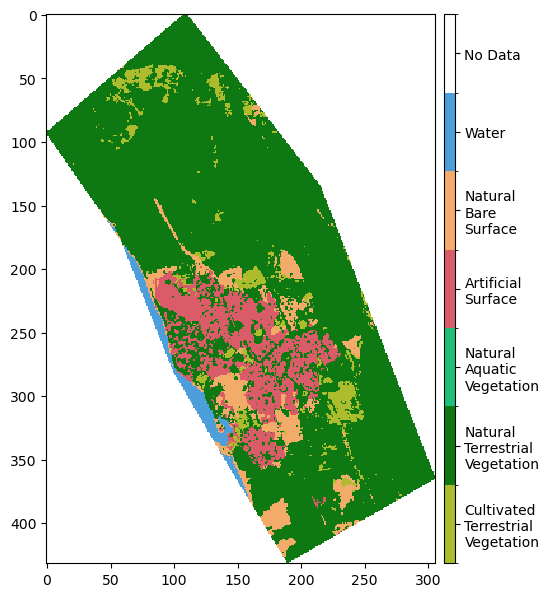

In [8]:
plot_land_cover(lc_ds[lc_level], year=time_range[0], width_pixels=400)

### Extract the data and view the tabular output

In [9]:
# extract the data using the function defined above and save the output table to a new variable
df = extract_data_from_roi(lc_ds, ROI_id, lc_level, classes_list=classes_list)

# visualise the output table
df.head(10)

Adding data to the output table...
Done!


,ROI_name,year,lc_level,class_value,class_label,class_pixels,area_m2,area_km2,ha
0,QuinnsRocks_WA,2000,level3,112,Natural Terrestrial Vegetation,45741,41166900.0,41.1669,4116.69
1,QuinnsRocks_WA,2001,level3,112,Natural Terrestrial Vegetation,38105,34294500.0,34.2945,3429.45
2,QuinnsRocks_WA,2002,level3,112,Natural Terrestrial Vegetation,38547,34692300.0,34.6923,3469.23
3,QuinnsRocks_WA,2003,level3,112,Natural Terrestrial Vegetation,40893,36803700.0,36.8037,3680.37
4,QuinnsRocks_WA,2004,level3,112,Natural Terrestrial Vegetation,36856,33170400.0,33.1704,3317.04
5,QuinnsRocks_WA,2005,level3,112,Natural Terrestrial Vegetation,36785,33106500.0,33.1065,3310.65
6,QuinnsRocks_WA,2006,level3,112,Natural Terrestrial Vegetation,38432,34588800.0,34.5888,3458.88
7,QuinnsRocks_WA,2007,level3,112,Natural Terrestrial Vegetation,34865,31378500.0,31.3785,3137.85
8,QuinnsRocks_WA,2008,level3,112,Natural Terrestrial Vegetation,35994,32394600.0,32.3946,3239.46
9,QuinnsRocks_WA,2009,level3,112,Natural Terrestrial Vegetation,35383,31844700.0,31.8447,3184.47


### Save the output table into a CSV that can be used for further analyses

In [10]:
df.to_csv(f'count_pixels_and_area_{ROI_id}.csv',
          index=False)  # do not include Pandas index as a column when exporting the data

## Time series land cover class area

Once the data is extracted and stored in a table format, we can use it for several different analyses. Below, we map the change in land cover classes through time.

### Define a colour scheme that matches the DEA Land Cover palette

DEA Tools already provide colour schemes for each Land Cover level. However, they also include additional information besides the RGB values. Therefore, we will simplify those colour schemes and use them in the charts for data visualisation.

In [11]:
# use the LC level defined above to find the colour scheme
colour_scheme = get_colour_scheme(lc_level)

In [12]:
# modify colour scheme to make it ready to use in the charts below 
colours_dict = {} # dictionary where we will store the RGB values for every LC class

for key, value in colour_scheme.items(): 
    colours_dict[get_label(key, lc_level)] = [i/255 for i in value[:3]] # include only the first 3 elements of the colour_scheme, i.e. RGB values


### Visualising change in land cover classes 

The example below plots the area covered by each Land Cover class in each calendar year. This way, changes over time in land use and land cover (LULC) can be observed.

We use a stacked bar chart as an example of how the land cover data can be displayed, a simple time series line plot would also work.

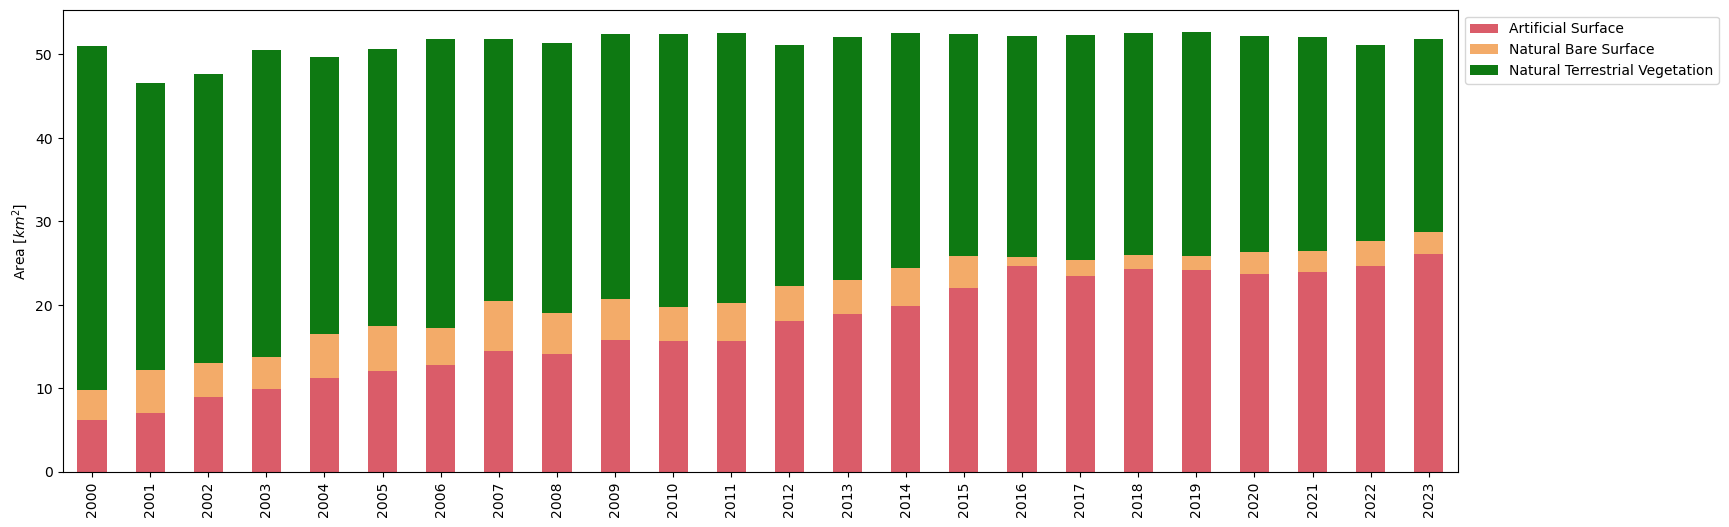

In [13]:
# transform the data set so that we have a column for each class,
pivot_df = df.pivot_table(
    index='year',  # use year as index for the rows,
    columns='class_label',  # and the unique classes labels as columns
    values=
    'area_km2',  # finally, populate the table with the area values for each year and class
)

# remove the "No Data" class, for improving the visualisation
if 'No Data' in pivot_df.columns:
    pivot_df = pivot_df.drop(columns=['No Data'])

pivot_df.plot(kind='bar', stacked=True, figsize=(18, 6), color=colours_dict)

plt.xlabel(None)
plt.ylabel('Area [$km^2$]')
# move legend outside the chart
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

From the stack plot, we can see that urban area has increased through time, leading to a reduction in terrestrial vegetation.

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** April 2025

**Compatible datacube version:** 

In [14]:
print(datacube.__version__)

1.8.19
